<a href="https://colab.research.google.com/github/NiroNithy/Personal_Portfolio/blob/Research/HNB_KNN_KFold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#LOAD THE DATA
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

df=pd.read_csv('/content/HNB Dataset.csv',encoding='ISO-8859-1')
df

,content,at,appVersion
0,Highly recommended â¤ï¸ very helful app â¤ï...,2025-01-27T10:45:15,6.5.2
1,Best banking app,2025-01-26T12:05:49,6.5.2
2,à®à®ªà¯à®ª à®ªà®¾à®°à¯ à®à®´à¯à®à¯à®à®...,2025-01-24T02:13:16,6.5.2
3,Nice,2025-01-24T00:11:44,6.5.2
4,There's nothing wrong with saying that.,2025-01-20T17:53:53,6.5.2
...,...,...,...
1412,"I heard something, earlier use this service fr...",2021-03-02T01:40:54,3.0.0
1413,It's very user friendly.,2021-03-02T01:29:07,3.0.0
1414,Very good app..easy use ðððððð,2021-03-02T00:41:03,3.0.0
1415,Easy to handle/ User friendly,2021-03-02T00:34:24,3.0.0


In [ ]:
# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return ' '.join(word for word in words if word.isalnum() and word not in stop_words)

In [ ]:
# Apply preprocessing to the content column
df['cleaned_content'] = df['content'].apply(preprocess_text)

In [ ]:
df

,content,at,appVersion,cleaned_content
0,Highly recommended â¤ï¸ very helful app â¤ï...,2025-01-27T10:45:15,6.5.2,highly recommended helful app
1,Best banking app,2025-01-26T12:05:49,6.5.2,best banking app
2,à®à®ªà¯à®ª à®ªà®¾à®°à¯ à®à®´à¯à®à¯à®à®...,2025-01-24T02:13:16,6.5.2,maintenence
3,Nice,2025-01-24T00:11:44,6.5.2,nice
4,There's nothing wrong with saying that.,2025-01-20T17:53:53,6.5.2,nothing wrong saying
...,...,...,...,...
1412,"I heard something, earlier use this service fr...",2021-03-02T01:40:54,3.0.0,heard something earlier use service free charg...
1413,It's very user friendly.,2021-03-02T01:29:07,3.0.0,user friendly
1414,Very good app..easy use ðððððð,2021-03-02T00:41:03,3.0.0,good app easy use
1415,Easy to handle/ User friendly,2021-03-02T00:34:24,3.0.0,easy user friendly


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Vectorizer the data
#vectorizer = TfidfVectorizer()
#X_Vector = vectorizer.fit_transform(df['cleaned_content'])

In [ ]:
#Initialize VADER Sentiment Analyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
#Take Sentiment Score
def classify_sentiment(score):
  if score >= 0.05:
    return 'positive'
  elif score <= 0.05:
    return 'negative'
  else:
    return 'netural'

#new output column as sentiment score(value)
df['sentiment_score'] = df['content'].apply(lambda x:sia.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

In [ ]:
df

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
0,Highly recommended â¤ï¸ very helful app â¤ï...,2025-01-27T10:45:15,6.5.2,highly recommended helful app,0.2716,positive
1,Best banking app,2025-01-26T12:05:49,6.5.2,best banking app,0.6369,positive
2,à®à®ªà¯à®ª à®ªà®¾à®°à¯ à®à®´à¯à®à¯à®à®...,2025-01-24T02:13:16,6.5.2,maintenence,0.0000,negative
3,Nice,2025-01-24T00:11:44,6.5.2,nice,0.4215,positive
4,There's nothing wrong with saying that.,2025-01-20T17:53:53,6.5.2,nothing wrong saying,0.3724,positive
...,...,...,...,...,...,...
1412,"I heard something, earlier use this service fr...",2021-03-02T01:40:54,3.0.0,heard something earlier use service free charg...,-0.2617,negative
1413,It's very user friendly.,2021-03-02T01:29:07,3.0.0,user friendly,0.5390,positive
1414,Very good app..easy use ðððððð,2021-03-02T00:41:03,3.0.0,good app easy use,0.4927,positive
1415,Easy to handle/ User friendly,2021-03-02T00:34:24,3.0.0,easy user friendly,0.7269,positive


In [ ]:
#Filter rows with negative sentiment
negative_reviews = df[df['sentiment'] == 'negative']

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,1099
negative,318


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
2,à®à®ªà¯à®ª à®ªà®¾à®°à¯ à®à®´à¯à®à¯à®à®...,2025-01-24T02:13:16,6.5.2,maintenence,0.0000,negative
14,Prompts a message as a rooted device for pixel...,2024-12-25T21:42:32,6.5.2,prompts message rooted device pixel devices,0.0000,negative
17,The OTP with 30sec time limit is such an incon...,2024-12-20T18:24:30,6.5.2,otp 30sec time limit inconvenience especially ...,-0.4881,negative
18,R r age.' Ric+Â¥! nd ',2024-12-20T05:42:35,6.3.1,r r age nd,0.0000,negative
19,"Parami Parami ooooc, nsm jjjbbggggnn..kk llllk...",2024-12-15T10:05:49,6.3.1,parami parami ooooc nsm jjjbbggggnn kk llllkkk...,0.0000,negative
...,...,...,...,...,...,...
1356,ðâ¤ï¸â¤ï¸,2021-04-19T12:37:44,3.0.0,,0.0000,negative
1386,ððððð,2021-03-06T10:23:43,3.0.0,,0.0000,negative
1390,Not supportive.Username doesn't work,2021-03-04T07:04:36,3.0.0,work,0.0000,negative
1405,Very user-friendly,2021-03-02T09:59:41,3.0.0,,0.0000,negative


In [ ]:
#Convert text to a Bag-of-Words representation
#vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
#dtm = vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Convert text to a TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_dtm = tfidf_vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=2, random_state=42)  # Assume 2 topics (UI, UX)
lda.fit(tfidf_dtm)

LatentDirichletAllocation(n_components=2, random_state=42)

In [ ]:
# Extract keywords for each topic
def get_top_keywords(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx + 1}"] = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
    return topics

n_top_words = 20
feature_names = tfidf_vectorizer.get_feature_names_out()
topics = get_top_keywords(lda, feature_names, n_top_words)

In [ ]:
print("Identified Topics with Keywords:")
for topic, keywords in topics.items():
   print(f"{topic}: {', '.join(keywords)}")

Identified Topics with Keywords:
Topic 1: sri, hnb, online, issue, phone, says, days, worst, poor, good, bank, banking, rooted, login, device, use, work, convenient, update, app
Topic 2: times, money, smooth, problem, works, service, ca, card, otp, properly, usefull, transfer, password, new, customer, account, fast, time, app, working


In [ ]:
# Extract the word-topic matrix from the LDA model
topic_word_matrix = lda.components_

In [ ]:
# Create a DataFrame for better visualization and ranking
keywords_ranking = {}

In [ ]:
for topic_idx, topic_weights in enumerate(topic_word_matrix):
    # Get the feature names (keywords)
    keywords = feature_names

    # Create a DataFrame with keywords and their importance scores
    keyword_scores = pd.DataFrame({
        'Keyword': keywords,
        'Importance': topic_weights
    })

    # Sort by importance in descending order
    keyword_scores = keyword_scores.sort_values(by='Importance', ascending=False)

    # Add to the dictionary
    keywords_ranking[f"Topic {topic_idx + 1}"] = keyword_scores

In [ ]:
# Display the rankings for each topic
for topic, df in keywords_ranking.items():
    print(f"\n{topic} - Top Keywords with Importance:")
    print(df.head(20))  # Display the top 10 keywords for each topic


Topic 1 - Top Keywords with Importance:
        Keyword  Importance
13          app   25.780491
227      update   13.472527
47   convenient   10.722229
249        work    8.236950
231         use    7.640267
62       device    6.807946
125       login    6.782497
176      rooted    6.110487
27      banking    6.013677
26         bank    5.469220
91         good    5.429795
160        poor    5.408348
253       worst    5.326756
55         days    5.080379
180        says    5.074751
154       phone    4.561728
110       issue    4.083136
144      online    4.020312
96          hnb    3.921206
200         sri    3.636889

Topic 2 - Top Keywords with Importance:
      Keyword  Importance
250   working   12.049398
13        app    9.526165
213      time    9.277886
79       fast    6.513445
6     account    5.397812
53   customer    4.937463
139       new    4.597474
150  password    4.561599
220  transfer    4.483638
233   usefull    4.344662
163  properly    3.953690
148       otp    3

In [ ]:
#Assign the most probable topic to each review
negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)

<ipython-input-23-1c6ee9867e2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)


In [ ]:
#negative_reviews

In [ ]:
# Map topic numbers to labels
topic_labels = {0: 'UI', 1: 'UX'}
negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)

<ipython-input-24-6f27e2f65528>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment,topic,classification
2,à®à®ªà¯à®ª à®ªà®¾à®°à¯ à®à®´à¯à®à¯à®à®...,2025-01-24T02:13:16,6.5.2,maintenence,0.0000,negative,0,UI
14,Prompts a message as a rooted device for pixel...,2024-12-25T21:42:32,6.5.2,prompts message rooted device pixel devices,0.0000,negative,0,UI
17,The OTP with 30sec time limit is such an incon...,2024-12-20T18:24:30,6.5.2,otp 30sec time limit inconvenience especially ...,-0.4881,negative,1,UX
18,R r age.' Ric+Â¥! nd ',2024-12-20T05:42:35,6.3.1,r r age nd,0.0000,negative,0,UI
19,"Parami Parami ooooc, nsm jjjbbggggnn..kk llllk...",2024-12-15T10:05:49,6.3.1,parami parami ooooc nsm jjjbbggggnn kk llllkkk...,0.0000,negative,0,UI
...,...,...,...,...,...,...,...,...
1356,ðâ¤ï¸â¤ï¸,2021-04-19T12:37:44,3.0.0,,0.0000,negative,0,UI
1386,ððððð,2021-03-06T10:23:43,3.0.0,,0.0000,negative,0,UI
1390,Not supportive.Username doesn't work,2021-03-04T07:04:36,3.0.0,work,0.0000,negative,0,UI
1405,Very user-friendly,2021-03-02T09:59:41,3.0.0,,0.0000,negative,0,UI


In [ ]:
negative_reviews['classification'].value_counts()

,count
classification,
UI,213
UX,105


In [ ]:
# Split the data into training and testing sets
X = tfidf_dtm.toarray()
Y = negative_reviews['classification'].apply(lambda x: 0 if x == 'UI' else 1)

In [ ]:
# K-Fold Cross-Validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
mse_values = []

In [ ]:
# Initialize KNN
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
# Ensure X and Y are NumPy arrays
X = np.array(X)  # Convert X to a NumPy array if it isn't already
Y = np.array(Y)  # Convert Y to a NumPy array if it isn't already

In [ ]:
for train_index, test_index in kf.split(X, Y):
    # Direct indexing for NumPy arrays
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    # Train and evaluate KNN
    knn.fit(X_train, Y_train)
    Y_pred = knn.predict(X_test)
    fold_accuracies.append(accuracy_score(Y_test, Y_pred))

    # Calculate MSE (Mean Squared Error)
    mse_values.append(mean_squared_error(Y_test, Y_pred))


In [ ]:
# Print results
print(f"KNN Fold Accuracies: {fold_accuracies}")
print(f"KNN Mean Accuracy: {sum(fold_accuracies) / len(fold_accuracies):.2f}")


KNN Fold Accuracies: [0.703125, 0.71875, 0.71875, 0.7301587301587301, 0.7301587301587301]
KNN Mean Accuracy: 0.72


In [ ]:
print(f"KNN Fold MSE Values: {mse_values}")
print(f"KNN Mean MSE: {sum(mse_values) / len(mse_values):.2f}")

KNN Fold MSE Values: [0.296875, 0.28125, 0.28125, 0.2698412698412698, 0.2698412698412698]
KNN Mean MSE: 0.28


In [ ]:
# Detailed Classification Report
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=['UI', 'UX']))
# Or individual scores
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Classification Report:
              precision    recall  f1-score   support

          UI       0.71      1.00      0.83        42
          UX       1.00      0.19      0.32        21

    accuracy                           0.73        63
   macro avg       0.86      0.60      0.58        63
weighted avg       0.81      0.73      0.66        63

Precision: 1.00
Recall: 0.19
F1 Score: 0.32


In [ ]:
# Confusion Matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(Y_test, Y_pred)
print(conf_matrix)


Confusion Matrix:
[[42  0]
 [17  4]]


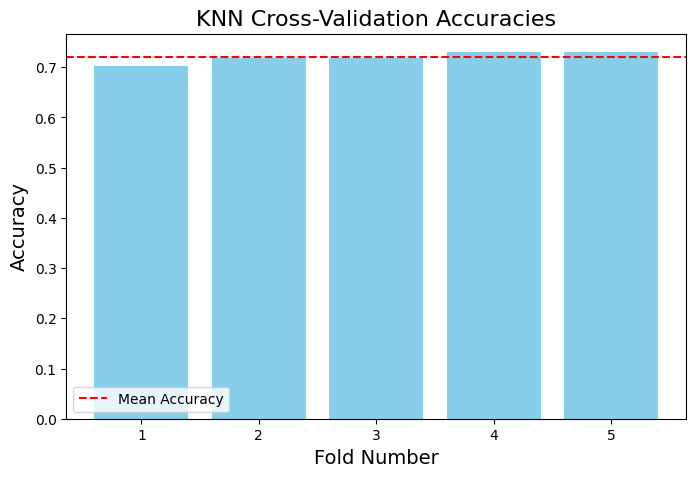

In [ ]:
# Plot the accuracies
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(fold_accuracies) + 1), fold_accuracies, color='skyblue')
plt.axhline(y=np.mean(fold_accuracies), color='r', linestyle='--', label='Mean Accuracy')
plt.title('KNN Cross-Validation Accuracies', fontsize=16)
plt.xlabel('Fold Number', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(range(1, len(fold_accuracies) + 1))
plt.legend()
plt.show()